In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md


/kaggle/input/datasets/letslen/student/Student_Mental_Health_Academic_Pressure_2025.csv - Form Responses 1.csv
/kaggle/input/datasets/letslen/student-mental-health-academic-pressure-2025-csv/student-mental-health-and-academic-pressure


In [3]:
import pandas as pd

file_path = '/kaggle/input/datasets/letslen/student/Student_Mental_Health_Academic_Pressure_2025.csv - Form Responses 1.csv'

df = pd.read_csv(file_path)

df.head()

,Timestamp,Age Group,Gender\n,Current Education Level,How much academic pressure do you feel?,How often do you feel stressed due to studies?,How many hours do you sleep on average per night?,What is the main cause of your academic stress?
0,12/13/2025 6:18,15–18,Female,College,4,Sometimes,7–8,1 .Exam and grades pressure
1,12/13/2025 6:24,15–18,Male,College,4,Often,5–6,Exams and Grades Pressure
2,12/13/2025 6:29,15–18,Female,University,3,Sometimes,7–8,financial conditions
3,12/13/2025 7:36,27+,Male,Other,1,Always,7–8,Other
4,12/13/2025 8:01,15–18,Female,College,2,Sometimes,5–6,Prefer not to say


In [4]:
# Missing values
df.isnull().sum()

Timestamp                                                0
Age Group                                                0
  Gender\n                                               0
  Current Education Level                                0
  How much academic pressure do you feel?                0
 How often do you feel stressed due to studies?          0
  How many hours do you sleep on average per night?      0
  What is the main cause of your academic stress?        0
dtype: int64

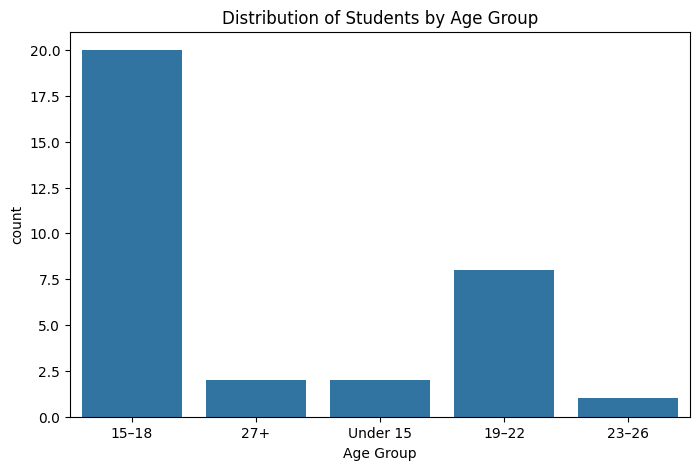

Insights: Most respondents are between 15–18 years old, indicating that the survey primarily represents younger students.


In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

#Age Group Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='Age Group')
plt.title('Distribution of Students by Age Group')
plt.show()

print('Insights: Most respondents are between 15–18 years old, indicating that the survey primarily represents younger students.')

['Timestamp', 'Age Group', 'Gender', 'Current Education Level', 'How much academic pressure do you feel?', 'How often do you feel stressed due to studies?', 'How many hours do you sleep on average per night?', 'What is the main cause of your academic stress?']


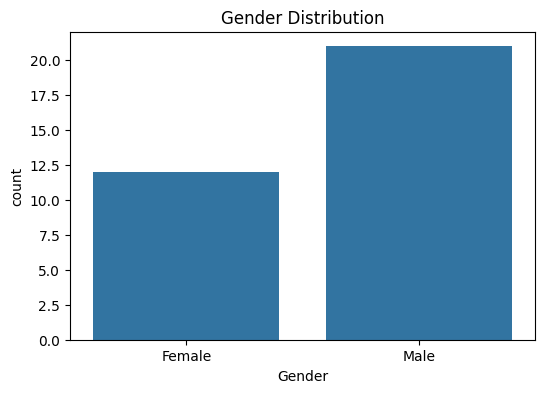

In [6]:
# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Verify columns
print(df.columns.tolist())

# Plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender')
plt.title('Gender Distribution')
plt.show()

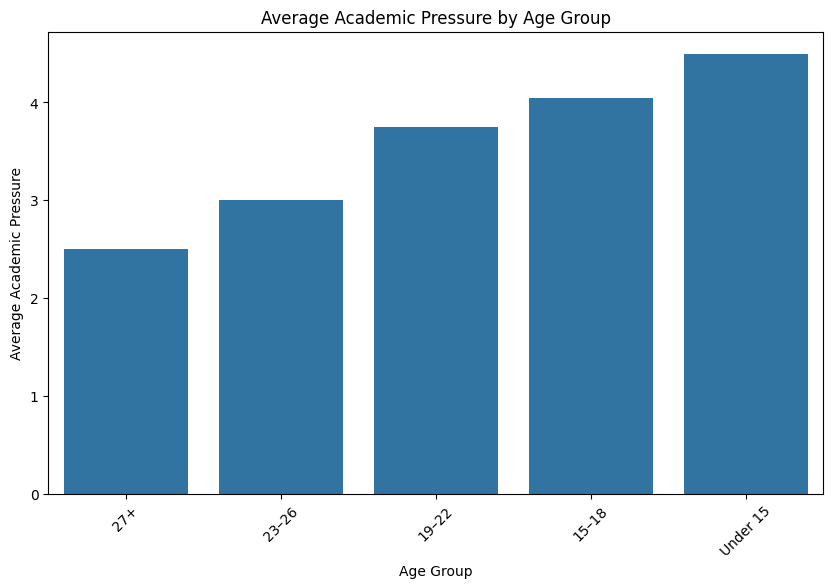

In [7]:
# Column names (adjust if necessary)
age_col = 'Age Group'
pressure_col = 'How much academic pressure do you feel?'

# Calculate mean academic pressure by age group
age_pressure = df.groupby(age_col)[pressure_col].mean().reset_index()

# Sort age groups if desired
age_pressure = age_pressure.sort_values(by=pressure_col)

# Create visualization
plt.figure(figsize=(10,6))
sns.barplot(data=age_pressure,
            x=age_col,
            y=pressure_col)

plt.title('Average Academic Pressure by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Academic Pressure')
plt.xticks(rotation=45)
plt.show()

In [8]:
# Clean column names
df.columns = df.columns.str.strip()

# Find relevant columns automatically
gender_col = [col for col in df.columns if 'gender' in col.lower()][0]
pressure_col = [col for col in df.columns if 'pressure' in col.lower()][0]

# Convert pressure column to numeric
df[pressure_col] = pd.to_numeric(df[pressure_col], errors='coerce')

# Calculate average pressure by gender
gender_pressure = df.groupby(gender_col)[pressure_col].mean().reset_index()

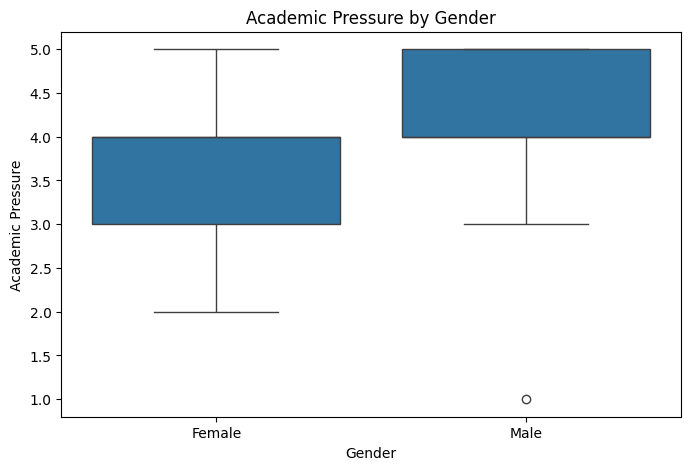

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x=gender_col,
            y=pressure_col)

plt.title('Academic Pressure by Gender')
plt.xlabel('Gender')
plt.ylabel('Academic Pressure')

plt.show()

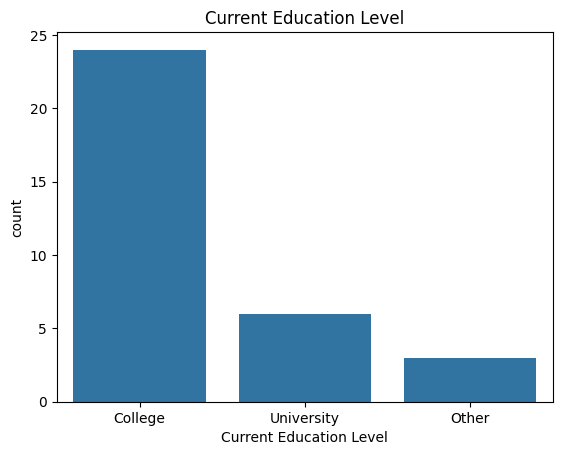

Insights: Most respondents are enrolled at college level.


In [10]:
#Education Level Distribution
edu_col = 'Current Education Level'

sns.countplot(data=df, x=edu_col)
plt.title('Current Education Level')
plt.show()

print('Insights: Most respondents are enrolled at college level.')

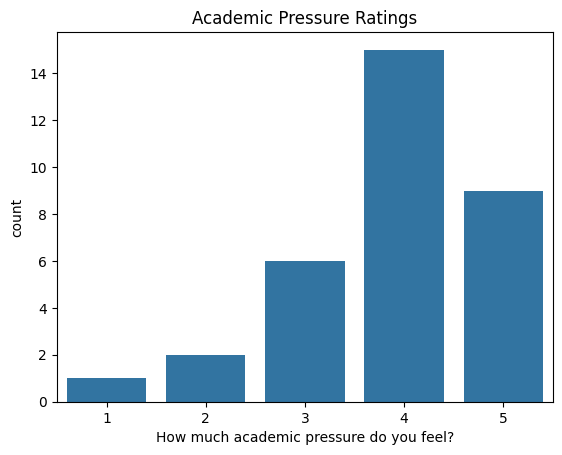

Insights: Many students report high levels of academic pressure (4–5).


In [11]:
#Academic Pressure Distribution
pressure_col = 'How much academic pressure do you feel?'

sns.countplot(data=df, x=pressure_col)
plt.title('Academic Pressure Ratings')
plt.show()

print('Insights: Many students report high levels of academic pressure (4–5).')

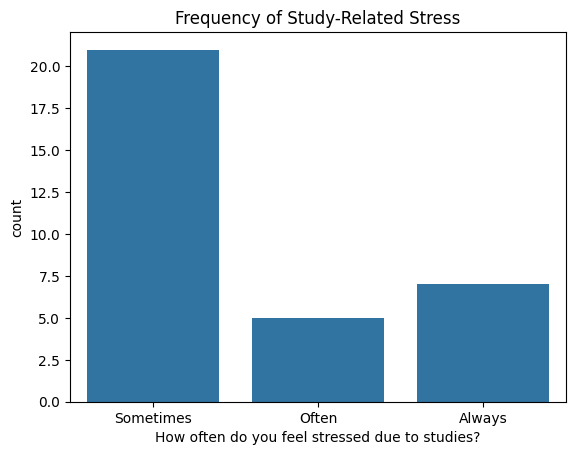

Insights: Most students report feeling stressed "Sometimes", while a notable proportion report "Always".


In [12]:
#Stress Frequency Distribution
stress_col = 'How often do you feel stressed due to studies?'

sns.countplot(data=df, x=stress_col)
plt.title('Frequency of Study-Related Stress')
plt.show()

print('Insights: Most students report feeling stressed "Sometimes", while a notable proportion report "Always".')

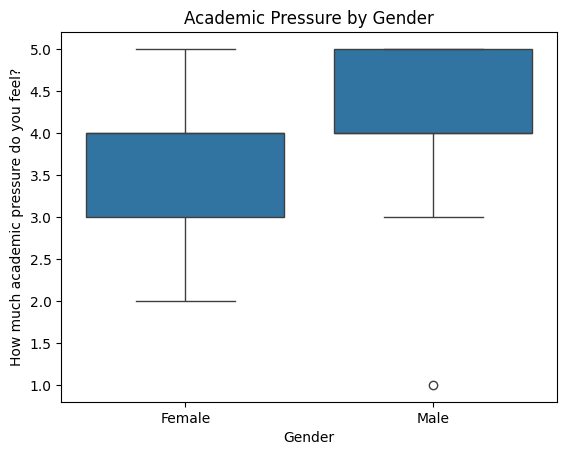

Insight: Allows comparison of perceived academic pressure between male and female students.


In [13]:
#Academic Pressure by Gender
sns.boxplot(
    data=df,
    x=gender_col,
    y=pressure_col
)

plt.title('Academic Pressure by Gender')
plt.show()

print('Insight: Allows comparison of perceived academic pressure between male and female students.')

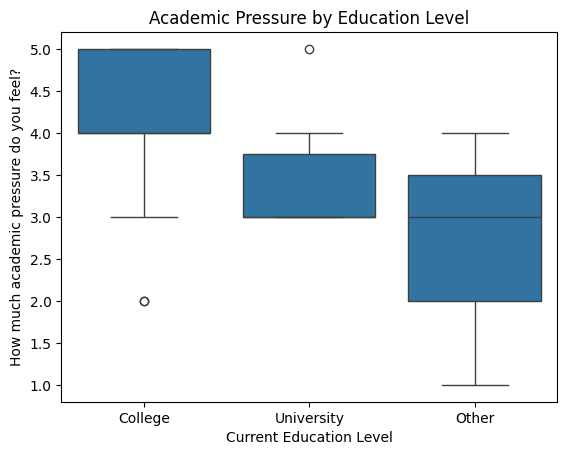

Shows whether university students experience greater pressure than college students.


In [14]:
#Academic Pressure by Education Level
sns.boxplot(
    data=df,
    x=edu_col,
    y=pressure_col
)

plt.title('Academic Pressure by Education Level')
plt.show()

print('Shows whether university students experience greater pressure than college students.')

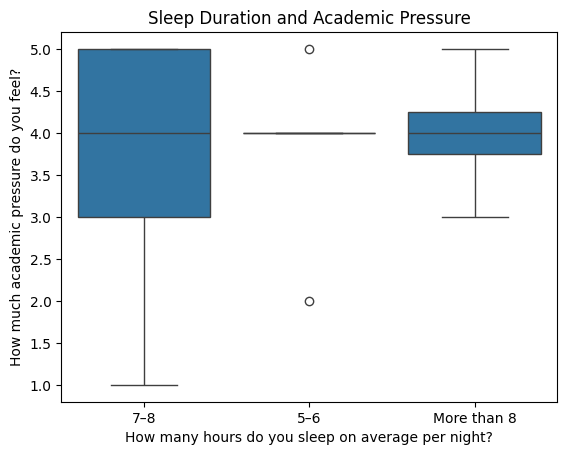

Examines whether students sleeping fewer hours report higher academic pressure.


In [15]:
#The relationship between Sleep duration and academic pressure
sleep_col = 'How many hours do you sleep on average per night?'

sns.boxplot(
    data=df,
    x=sleep_col,
    y=pressure_col
)

plt.title('Sleep Duration and Academic Pressure')
plt.show()

print('Examines whether students sleeping fewer hours report higher academic pressure.')

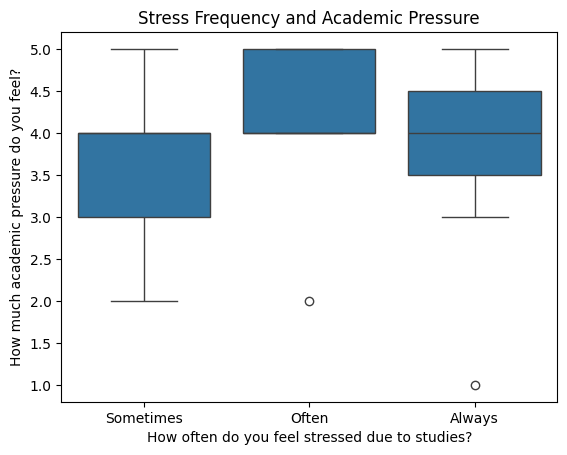

Insights: Students who report stress more frequently are expected to show higher academic pressure ratings.


In [16]:
#The relationship between Stress Frequency and Academic Pressure
sns.boxplot(
    data=df,
    x=stress_col,
    y=pressure_col
)

plt.title('Stress Frequency and Academic Pressure')
plt.show()
print('Insights: Students who report stress more frequently are expected to show higher academic pressure ratings.')

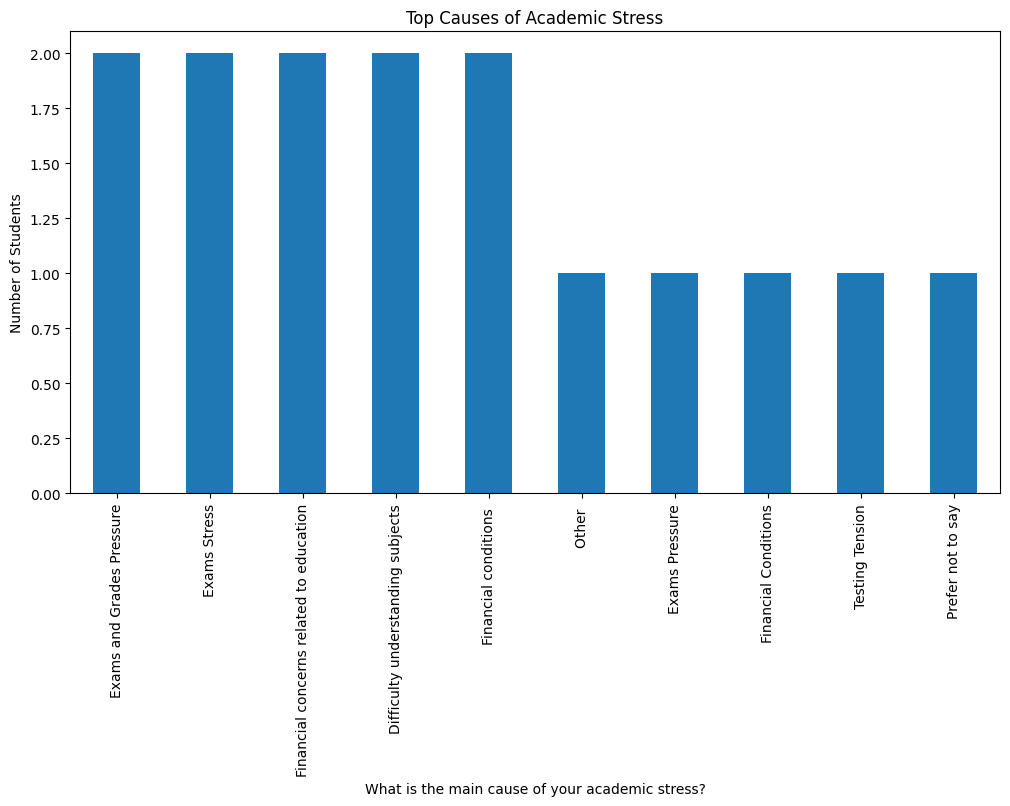

Insights: Dominant sources of academic stress among students are identified.


In [19]:
#Main causes of academic stress
cause_col = 'What is the main cause of your academic stress?'

plt.figure(figsize=(12,6))
df[cause_col].value_counts().head(10).plot(kind='bar')
plt.title('Top Causes of Academic Stress')
plt.ylabel('Number of Students')
plt.show()

print('Insights: Dominant sources of academic stress among students are identified.')